# Annotation overview: original vs annotated

This notebook loads a photo, runs SCRFD face detection, and displays the **unannotated** original alongside the **annotated** overlay (bboxes, landmarks, pose, attributes).

> **Setup:** from the repo root, run `pip install -e .` and `mf download` for model weights. Use a kernel from that environment.

In [3]:
import sys
from pathlib import Path

NOTEBOOKS_DIR = Path.cwd()
if NOTEBOOKS_DIR.name == "notebooks":
    REPO_ROOT = NOTEBOOKS_DIR.parent
else:
    REPO_ROOT = NOTEBOOKS_DIR
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
if str(NOTEBOOKS_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOKS_DIR))

from meta_face.annotate import draw_annotations
from meta_face.imaging import load_image
from meta_face.tools.face_record import resolve_face_records

import _utils

## User input

Set `IMAGE_PATH` to a local image file containing one or more faces.

In [4]:
IMAGE_PATH = Path("../test_images/20110903_172733.840.jpg")  # team photo
FORCE_DETECT = False  # True to re-run SCRFD instead of loading face.scrfd.* from .scar

if not IMAGE_PATH.is_file():
    raise FileNotFoundError(f"Set IMAGE_PATH to an existing image: {IMAGE_PATH}")

In [7]:
image = load_image(IMAGE_PATH)
records, source = resolve_face_records(IMAGE_PATH, force=True, image=image)
annotated = draw_annotations(image, records, dense_landmarks=True)

verb = "Detected" if source == "detect" else "Loaded"
print(f"{verb} {len(records)} face(s) from {source} in {IMAGE_PATH.name}")

Applied providers: ['CUDAExecutionProvider', 'CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}, 'CUDAExecutionProvider': {'sdpa_kernel': '0', 'use_tf32': '1', 'fuse_conv_bias': '0', 'prefer_nhwc': '0', 'tunable_op_max_tuning_duration_ms': '0', 'enable_skip_layer_norm_strict_mode': '0', 'tunable_op_tuning_enable': '0', 'tunable_op_enable': '0', 'use_ep_level_unified_stream': '0', 'device_id': '0', 'has_user_compute_stream': '0', 'gpu_external_empty_cache': '0', 'cudnn_conv_algo_search': 'EXHAUSTIVE', 'cudnn_conv1d_pad_to_nc1d': '0', 'gpu_mem_limit': '18446744073709551615', 'gpu_external_alloc': '0', 'gpu_external_free': '0', 'arena_extend_strategy': 'kNextPowerOfTwo', 'do_copy_in_default_stream': '1', 'enable_cuda_graph': '0', 'user_compute_stream': '0', 'cudnn_conv_use_max_workspace': '1'}}
find model: /home/jed/.insightface/models/buffalo_l/1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CUDAExecutionProvider', 'CPUExecutionProvider'], wi

/projects/spring_photography/meta_face/venv_meta_face/lib/python3.11/site-packages/insightface/utils/face_align.py:23: FutureWarning: `estimate` is deprecated since version 0.26 and will be removed in version 2.2. Please use `SimilarityTransform.from_estimate` class constructor instead.
  tform.estimate(lmk, dst)


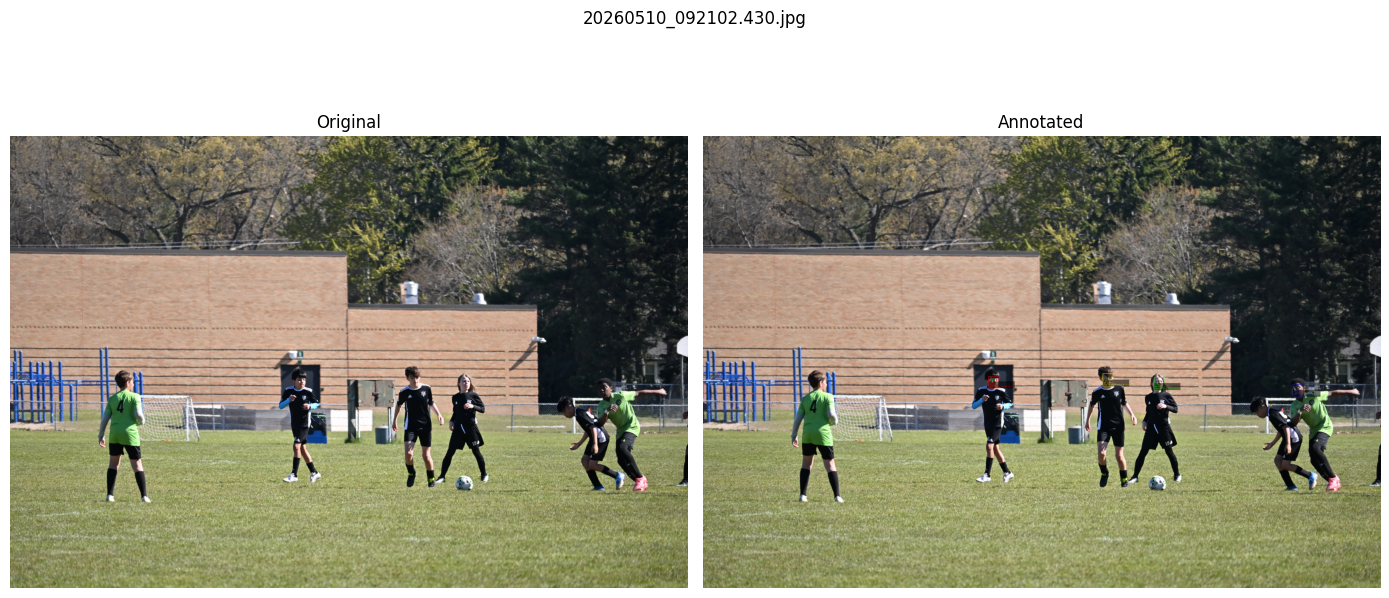

In [8]:
_utils.show_original_and_annotated(image, annotated, title=IMAGE_PATH.name)

In [9]:
for idx, record in enumerate(records):
    bbox = record["bbox"]
    score = record.get("det_score")
    print(f"Face {idx + 1}: bbox={[round(v, 1) for v in bbox]}, det_score={score:.3f}" if score else f"Face {idx + 1}: bbox={bbox}")

Face 1: bbox=[2343.5, 1973.7, 2425.3, 2069.8], det_score=0.723
Face 2: bbox=[3705.0, 1984.1, 3784.9, 2084.0], det_score=0.678
Face 3: bbox=[4845.5, 2037.6, 4930.6, 2141.1], det_score=0.610
Face 4: bbox=[3283.9, 1951.1, 3366.8, 2056.4], det_score=0.587
